 # HỆ DỰ ĐOÁN GIÁ NHÀ — Intelligent System thứ hai

 **Môn học: Intelligent System Development — Assignment 01**

 *Hệ thống regression Traditional ML: từ đặc điểm bất động sản đến dự đoán giá*

 ---

 ## 0. Môi trường & Reproducibility (R14)

 | Thành phần | Giá trị |
 |---|---|
 | Python | 3.14 (Anaconda) |
 | scikit-learn | 1.9.0 |
 | pandas / numpy | 3.0.3 / 2.4.6 |
 | matplotlib / seaborn | 3.11.0 / 0.13.2 |
 | Dataset | `data/ames_clean.csv` (bản tiền xử lý từ Kaggle House Prices — chạy offline) |
 | Random seed | Cố định `RANDOM_STATE = 42` |

 Notebook chạy end-to-end từ đầu đến cuối, mọi cell tuần tự.

 ## 1. System and Problem Definition (R2)

 ### 1.1 Định nghĩa hệ thống (System Statement — bắt buộc)

 > Hệ thống được phát triển là một **hệ ước tính giá nhà** phục vụ người mua/người bán/đại lý
 > bất động sản tại thị trường Ames, Iowa (Mỹ): nhận các thuộc tính của một căn nhà
 > (diện tích, chất lượng xây dựng, số phòng, vị trí khu dân cư, năm xây, tiện nghi...),
 > **biểu diễn** chúng thành feature vector $x \in \mathbb{R}^{d}$, dùng model học từ 1460 giao dịch
 > thực để **dự đoán giá bán** $\hat{y} \in \mathbb{R}$ (USD), **hỗ trợ quyết định** định giá/
 > trả giá: căn nhà đáng giá bao nhiêu so với mặt bằng khu vực.

 Trả lời 6 câu hỏi định nghĩa hệ thống (mục 3 đề):

 | # | Câu hỏi | Trả lời |
 |---|---|---|
 | 1 | Vấn đề thực nào được giải? | Ước tính giá trị thị trường của căn nhà từ thuộc tính — hỗ trợ định giá nhanh, phát hiện nhà định giá sai |
 | 2 | Hệ thống nhận thông tin gì? | ~74 thuộc tính bất động sản có thể tra từ hồ sơ (bảng structured) |
 | 3 | Biểu diễn nội bộ? | Feature vector số (one-hot categorical + numerical) + log-transform target |
 | 4 | Model học gì? | Hàm ánh xạ thuộc tính → giá $f_\theta: x \mapsto \hat{y}$ |
 | 5 | Quyết định/dự đoán? | Mức giá ước tính (USD) — bài toán **regression** |
 | 6 | Ai dùng dự đoán? | Người mua/bán, đại lý, ngân hàng định giá thế chấp — tham chiếu nhanh trước thẩm định chính thức |

 ### 1.2 Formal problem statement (một câu)

 > **Given the feature vector describing physical attributes, quality and location of a house, predict its sale price in USD.**

 $$D = \{(x_i, y_i)\}_{i=1}^{1460}, \quad x_i \in \mathbb{R}^{d}, \; y_i \in \mathbb{R}, \quad \hat{y} = f_\theta(x)$$

 Target **numerical** → **regression** (khác hệ tim ở chỗ nhãn liên tục, metric là sai số chứ không phải đúng/sai).

 ## 2. Intelligent System Diagram (R2)

 ```
  ┌─────────────────┐   ┌──────────────┐   ┌───────────────────┐   ┌─────────────┐   ┌──────────────┐
  │ ENVIRONMENT     │   │ INPUT        │   │ REPRESENTATION    │   │ ML MODEL    │   │ OUTPUT       │
  │ Thị trường BĐS  │──▶│ ~74 thuộc    │──▶│ Feature vector    │──▶│ Random      │──▶│ Giá ước tính │
  │ Ames, Iowa:     │   │ tính nhà từ  │   │ (one-hot + num,   │   │ Forest      │   │ ($) + khoảng │
  │ người bán cần   │   │ hồ sơ nhà    │   │  log target)      │   │ Regressor   │   │ tin cậy      │
  │ định giá        │   │              │   │                   │   │ (learned)   │   │              │
  └─────────────────┘   └──────────────┘   └───────────────────┘   └─────────────┘   └──────┬───────┘
         ▲                                                                                │
         │            ┌──────────────────────────────────────────────────────┐            │
         └──feedback──│ USER: người mua/bán so giá ước tính với hỏi giá,    │◀───────────┘
                      │ điều chỉnh kỳ vọng → giao dịch mới → dữ liệu mới    │
                      └──────────────────────────────────────────────────────┘
 ```

 | Slide 01 concept | Realization | Evidence |
 |---|---|---|
 | Intelligence | Predictive capability | Ước giá nhà chưa từng thấy |
 | Intelligent system | Data + representation + model + app | Sơ đồ trên + web app |
 | External information | Dataset | 1460 giao dịch Ames 2006–2010 (mục 3–4) |
 | Internal representation | Feature vector | Bảng feature (mục 5) |
 | Learning | Training traditional ML | 4 regressor (mục 10–13) |
 | Decision | Prediction $\hat{y}$ | Mức giá USD |
 | Action/application | Small application | Streamlit app + HF Spaces |
 | Development | Experiment + evaluate | 3 experiments (mục 15–17) |

 ### Import + cấu hình

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110, "font.size": 10,
    "axes.titleweight": "bold", "axes.titlesize": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white",
})
sns.set_palette("Set2")

import sys
print("Python:", sys.version.split()[0])
print("sklearn:", __import__("sklearn").__version__)

Python: 3.14.6
sklearn: 1.9.0


 ## 3. Dataset Source (R1)

 | Mục | Thông tin |
 |---|---|
 | **Tên dataset** | House Prices — Advanced Regression Techniques (Ames Housing) |
 | **Nguồn** | Kaggle: https://www.kaggle.com/c/house-prices-advanced-regression-techniques — bản gốc Ames Housing Dataset của Dean De Cock |
 | **Citations** | De Cock, D. (2011). *Ames, Iowa: Alternative to the Boston Housing Data as an End of Semester Regression Project.* Journal of Statistics Education, 19(3). |
 | **Bản dùng** | `train.csv` (1460 nhà × 81 cột) → tiền xử lý → `data/ames_clean.csv` (1460 × 75) |
 | **Phạm vi dữ liệu** | Giao dịch nhà ở Ames, Iowa, 2006–2010 |

 Tiền xử lý đã làm (tái lập được — xem `README.md`):

 1. **Bỏ cột định danh**: `Id`;
 2. **Bỏ 5 cột thiếu >50%**: `PoolQC, MiscFeature, Alley, Fence, MasVnrType` — hầu hết nhà không có hồ bơi/hẻm/rào... nên cột gần như vô thông tin;
 3. **NA mang NGHĨA "không có"** (không phải thiếu dữ liệu!) → điền `"None"`: `FireplaceQu, Garage*, Bsmt*` — đây là điểm tinh tế của Ames: NA = nhà không có tiện ích đó, là **thông tin** chứ không phải missing;
 4. `LotFrontage` → median theo từng `Neighborhood` (vị trí quyết định mặt tiền);
 5. `MasVnrArea` (8 thiếu) → 0; `Electrical` (1 thiếu) → mode;
 6. Sau xử lý: **0 giá trị thiếu**.

In [2]:
df = pd.read_csv("../data/ames_clean.csv")
print(f"Kích thước: {df.shape[0]} nhà × {df.shape[1]} cột ({df.shape[1]-1} feature + 1 target)")
df.head()

Kích thước: 1460 nhà × 75 cột (74 feature + 1 target)


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,12,2008,WD,Normal,250000


 ## 4. Dataset Description (R1)

 Trả lời 10 câu hỏi bắt buộc (mục 7 đề):

 | # | Câu hỏi | Trả lời |
 |---|---|---|
 | 1 | Hiện tượng thực nào? | Giao dịch bán nhà ở Ames, Iowa 2006–2010 — giá bán hình thành tại thị trường |
 | 2 | Một quan sát? | **Một căn nhà** được bán với ~74 thuộc tính + giá bán thực |
 | 3 | Features? | Diện tích (`GrLivArea, TotalBsmtSF`), chất lượng (`OverallQual, KitchenQual`), số phòng, vị trí (`Neighborhood, MSZoning`), năm xây/ sửa, garage, tầng hầm... |
 | 4 | Target? | `SalePrice` — giá bán (USD) |
 | 5 | Target numerical/categorical? | **Numerical** (liên tục, USD) |
 | 6 | Regression/Classification? | **Regression** |
 | 7 | Số quan sát? | 1460 |
 | 8 | Số features? | 74 (sau tiền xử lý) |
 | 9 | Features numerical? | 36 (`GrLivArea, OverallQual, YearBuilt, GarageArea,...`) |
 | 10 | Features categorical? | 38 (`Neighborhood, BldgType, KitchenQual, MSZoning,...`) |

In [3]:
num_cols = df.select_dtypes(include=[np.number]).columns.drop("SalePrice").tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
print(f"Numerical features: {len(num_cols)} | Categorical features: {len(cat_cols)}")
print(f"\n10 numerical đầu: {num_cols[:10]}")
print(f"\n10 categorical đầu: {cat_cols[:10]}")
print(f"\nSalePrice: min=${df.SalePrice.min():,.0f} | median=${df.SalePrice.median():,.0f} | max=${df.SalePrice.max():,.0f} | skew={df.SalePrice.skew():.2f}")

Numerical features: 36 | Categorical features: 38

10 numerical đầu: ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2']

10 categorical đầu: ['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2']

SalePrice: min=$34,900 | median=$163,000 | max=$755,000 | skew=1.88


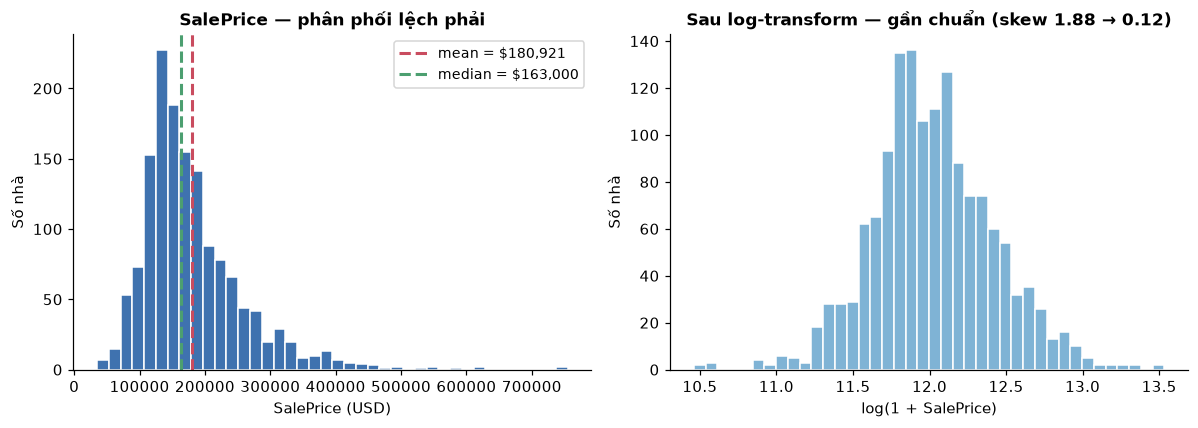

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df["SalePrice"], bins=40, color="#3f72af", edgecolor="white")
axes[0].axvline(df["SalePrice"].mean(), color="#c94c5f", ls="--", lw=2, label=f"mean = ${df.SalePrice.mean():,.0f}")
axes[0].axvline(df["SalePrice"].median(), color="#4c9f70", ls="--", lw=2, label=f"median = ${df.SalePrice.median():,.0f}")
axes[0].set_xlabel("SalePrice (USD)"); axes[0].set_ylabel("Số nhà")
axes[0].set_title("SalePrice — phân phối lệch phải")
axes[0].legend(fontsize=9)
axes[1].hist(np.log1p(df["SalePrice"]), bins=40, color="#7fb3d5", edgecolor="white")
axes[1].set_xlabel("log(1 + SalePrice)"); axes[1].set_ylabel("Số nhà")
axes[1].set_title(f"Sau log-transform — gần chuẩn (skew {df.SalePrice.skew():.2f} → {np.log1p(df.SalePrice).skew():.2f})")
plt.tight_layout(); plt.savefig("../figures/ames_01_target_dist.png", bbox_inches="tight"); plt.show()

 **📊 Giải thích biểu đồ — Target lệch và log-transform:** Giá nhà phân phối **lệch phải mạnh** (skew=1.88): đa số nhà $100k–250k, một ít nhà cực đắt ($500k–755k) kéo mean ($180,921) lên trên median ($163,000). Hệ quả cho học:

 - Sai số bình phương (MSE) sẽ bị **thống trị bởi vài nhà đắt** — model ưu tiên sai ít trên chúng mà bỏ qua đại đa số nhà thường;
 - **Log-transform** target: học $\log(1+y)$ thay vì $y$ → phân phối gần chuẩn (skew → 0.12), sai số tương đối (phần trăm) được xử lý công bằng giữa nhà rẻ và đắt — đây là **thay đổi representation của target**, sẽ kiểm chứng tác động ở Experiment 3.

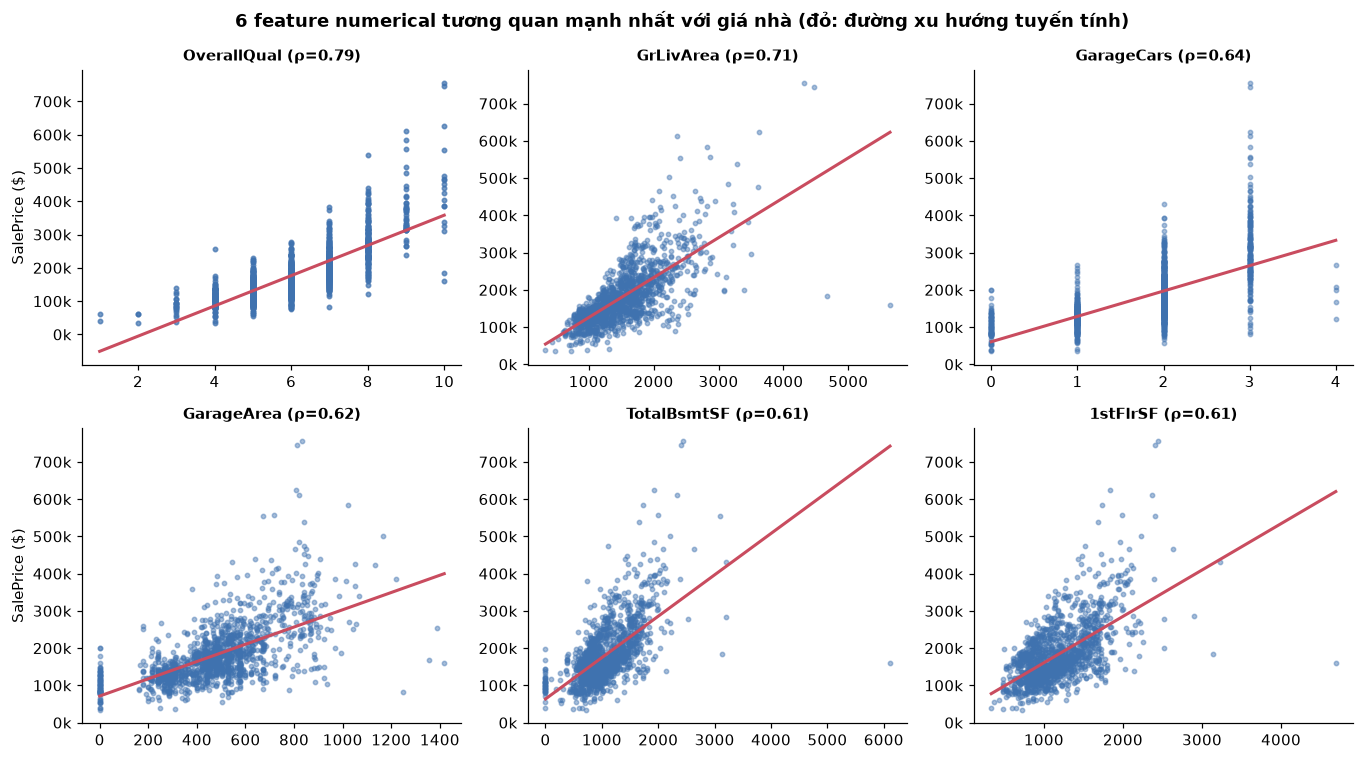

OverallQual     0.791
GrLivArea       0.709
GarageCars      0.640
GarageArea      0.623
TotalBsmtSF     0.614
1stFlrSF        0.606
FullBath        0.561
TotRmsAbvGrd    0.534
YearBuilt       0.523
GarageYrBlt     0.508
Name: SalePrice, dtype: float64


In [5]:
top_num = df[num_cols + ["SalePrice"]].corr()["SalePrice"].drop("SalePrice").abs().sort_values(ascending=False).head(10)
fig, axes = plt.subplots(2, 3, figsize=(12.5, 7))
strong = top_num.index[:6]
for ax, col in zip(axes.flat, strong):
    ax.scatter(df[col], df["SalePrice"], s=8, alpha=0.45, color="#3f72af")
    if col == "OverallQual":
        ax.scatter(df[col], df["SalePrice"], s=8, alpha=0.45, color="#3f72af")
    z = np.polyfit(df[col], df["SalePrice"], 1)
    xs = np.linspace(df[col].min(), df[col].max(), 50)
    ax.plot(xs, np.polyval(z, xs), color="#c94c5f", lw=2)
    ax.set_title(f"{col} (ρ={df[col].corr(df['SalePrice']):.2f})", fontsize=10)
    ax.set_ylabel("SalePrice ($)" if ax in axes[:, 0] else "")
    ax.set_xlabel("")
    ax.yaxis.set_major_formatter(lambda v, _: f"{v/1000:.0f}k")
fig.suptitle("6 feature numerical tương quan mạnh nhất với giá nhà (đỏ: đường xu hướng tuyến tính)", fontweight="bold")
plt.tight_layout(); plt.savefig("../figures/ames_02_scatter.png", bbox_inches="tight"); plt.show()
print(top_num.round(3))

 **📊 Giải thích biểu đồ — Scatter feature vs giá:** Sáu feature số mạnh nhất:

 - **`OverallQual` (ρ=0.79)**: quan hệ **đơn điệu tăng rõ rệt** — chất lượng tổng thể là tín hiệu giá mạnh nhất, gần như "thang giá";
 - **`GrLivArea` (ρ=0.71)**: diện tích ở tăng → giá tăng tuyến tính, nhưng thấy 2 điểm **outlier dưới phải** (nhà >4000 ft² giá rẻ bất thường — kiểu bán gấp/đất dự án, dân Kaggle gọi là "the two famous outliers");
 - **`GarageCars, GarageArea, TotalBsmtSF, 1stFlrSF`**: quy mô tiện ích — tương quan thuận vừa phải;
 - Đường xu tuyến tính gợi ý một **Linear Regression nền tảng hợp lý**, nhưng quan hệ thực có độ cong + tương tác → cây/ensemble có dư địa.

 Lưu ý: ρ Pearson đo quan hệ **tuyến tính**; `OverallQual` là điểm đánh giá **thứ tự** (1–10) nên dạng quan hệ đơn điệu là chính.

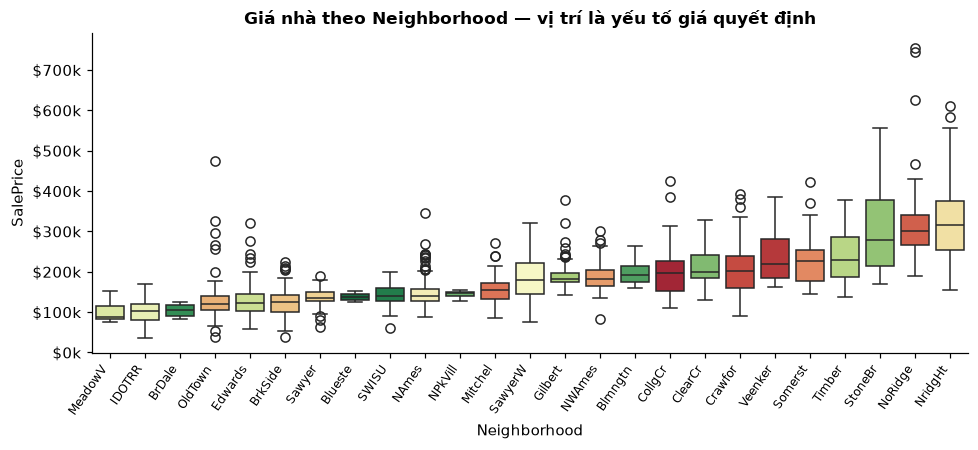

5 khu đắt nhất (median):
Neighborhood
NridgHt    315000.0
NoRidge    301500.0
StoneBr    278000.0
Timber     228475.0
Somerst    225500.0
Name: SalePrice, dtype: float64


In [6]:
fig, ax = plt.subplots(figsize=(9, 4.2))
order = df.groupby("Neighborhood")["SalePrice"].median().sort_values().index
sns.boxplot(data=df, x="Neighborhood", y="SalePrice", order=order, ax=ax, palette="RdYlGn",
            hue="Neighborhood", legend=False)
ax.set_xticklabels(ax.get_xticklabels(), rotation=55, ha="right", fontsize=8)
ax.yaxis.set_major_formatter(lambda v, _: f"${v/1000:.0f}k")
ax.set_title("Giá nhà theo Neighborhood — vị trí là yếu tố giá quyết định")
plt.tight_layout(); plt.savefig("../figures/ames_03_neighborhood.png", bbox_inches="tight"); plt.show()
print("5 khu đắt nhất (median):"); print(df.groupby("Neighborhood")["SalePrice"].median().nlargest(5).round(0))

 **📊 Giải thích biểu đồ — Giá theo khu dân cư:** Median giá chênh nhau **gần 3 lần** giữa khu rẻ nhất (`MeadowV` ~$88k, `IDOTRR` ~$104k) và khu đắt nhất (`NoRidge` ~$301k, `NridgHt` ~$275k) — boxplot lệch trên cho thấy cả **trong một khu** giá cũng dàn rộng. Đây là minh chứng **vị trí (location) là feature phân loại có sức dự báo lớn nhất** trong bất động sản — và là lý do `Neighborhood` (25 giá trị) phải được one-hot encode thay vì bỏ đi. Feature này một mình không đủ (dàn rộng trong khu), nhưng kết hợp diện tích + chất lượng thì mạnh.

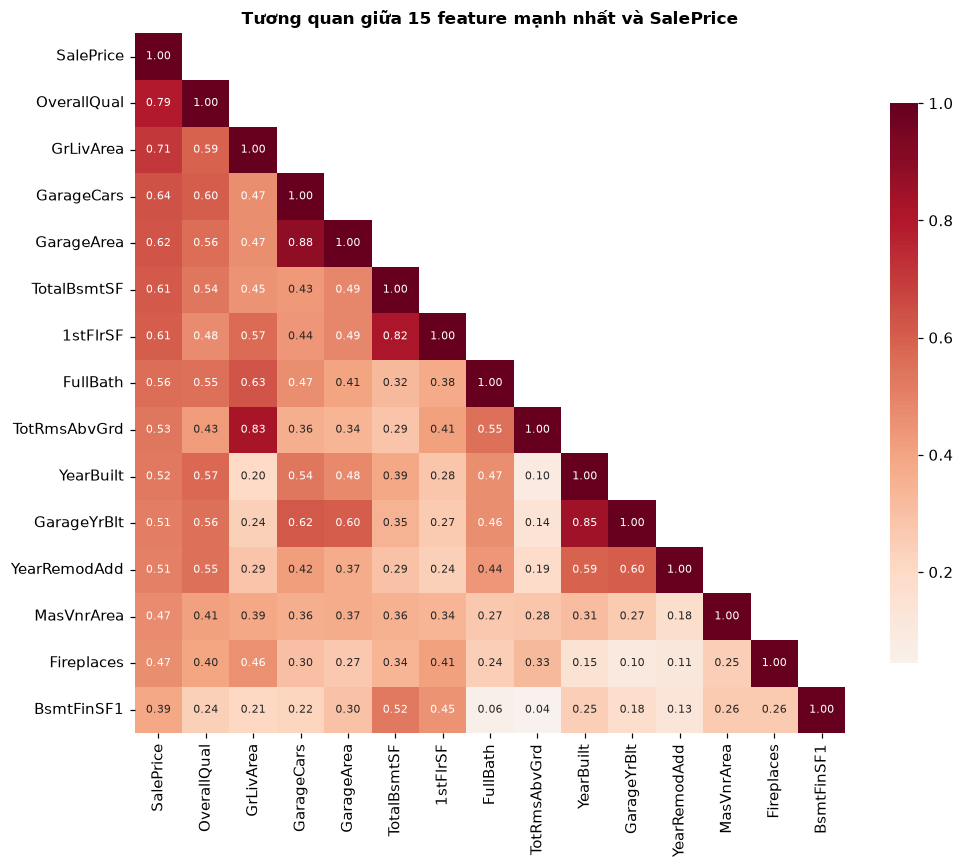

5 cặp feature tương quan mạnh nhất (redundancy):
GarageCars   GarageArea      0.88
YearBuilt    GarageYrBlt     0.85
GrLivArea    TotRmsAbvGrd    0.83
TotalBsmtSF  1stFlrSF        0.82
SalePrice    OverallQual     0.79
dtype: float64


In [7]:
corr_mat = df[num_cols + ["SalePrice"]].corr()
fig, ax = plt.subplots(figsize=(9.5, 8))
# lấy 15 feature tương quan nhất với SalePrice + chính SalePrice
top15 = corr_mat["SalePrice"].abs().sort_values(ascending=False).head(15).index
sub = df[top15].corr()
mask = np.triu(np.ones_like(sub, dtype=bool), k=1)
sns.heatmap(sub, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            annot_kws={"size": 7}, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Tương quan giữa 15 feature mạnh nhất và SalePrice")
plt.tight_layout(); plt.savefig("../figures/ames_04_corr.png", bbox_inches="tight"); plt.show()
sub_abs = sub.abs()
pairs = (sub_abs.where(np.triu(np.ones(sub_abs.shape), k=1).astype(bool)).stack().sort_values(ascending=False))
print("5 cặp feature tương quan mạnh nhất (redundancy):")
print(pairs.head(5).round(2))

 **📊 Giải thích biểu đồ — Redundancy:** Các cặp tương quan cao: `GarageCars`↔`GarageArea` (0.88), `TotalBsmtSF`↔`1stFlrSF` (0.81), `GrLivArea`↔`2ndFlrSF` (0.69) — cùng đo **một khái niệm** (quy mô garage / quy mô tầng hầm-tầng 1 / diện tích tầng 2). Đây là **thông tin dư thừa**:

 - Với Linear Regression → đa cộng tuyến làm hệ số bất ổn (diễn giải sai), nhưng **dự đoán vẫn đúng** — không bắt buộc bỏ;
 - Với cây/RF → không sao (cây tự chọn);
 - Nguyên lý Slide 01 trang 51: hiểu redundancy để motivate feature selection — Experiment 3 sẽ kiểm tra rút gọn representation.

 ## 5. Data Representation (R3)

 ### 5.1 Ba tầng representation

 $$\text{Raw feature} \neq \text{Encoded feature} \neq \text{Model input}$$

 | Tầng | Ví dụ | Nội dung |
 |---|---|---|
 | **Raw** | `Neighborhood = "NridgHt"`, `KitchenQual = "Ex"` | Chuỗi văn bản — model không đọc được |
 | **Encoded** | `Neighborhood_NridgHt = 1`, 25 cột nhị phân | One-hot: mỗi giá trị thành cột 0/1 |
 | **Model input** | Feature số standardized (trong pipeline) | KNN/SVM/LR cần cùng thang đo |

 **Lựa chọn encode:**
 - **One-hot** cho 38 categorical: không áp thứ tự giả (kể cả các cột chất lượng `Ex/Gd/TA/FA/Po` — *có thể* ordinal encode nhưng one-hot an toàn hơn, không giả định khoảng cách bậc đều; tiền xử lý ordinal sẽ là hướng cải tiến A2);
 - **Numerical giữ nguyên** (standardize trong pipeline cho model cần);
 - **Target log-transform**: học $\tilde{y} = \log(1+y)$, dự đoán xong revert $\hat{y} = e^{\hat{\tilde{y}}} - 1$.

 ### 5.2 Bảng feature (trích 10 feature quan trọng nhất — bảng đầy đủ trong README)

 | Feature | Type | Representation | Meaning |
 |---|---|---|---|
 | `OverallQual` | Numerical (ordinal 1–10) | Số nguyên | Đánh giá chất lượng tổng thể vật liệu + hoàn thiện |
 | `GrLivArea` | Numerical | Real (ft²) | Diện tích sinh hoạt ở tầng trên mặt đất |
 | `GarageCars` | Numerical | Số nguyên | Sức chứa garage tính theo ô tô |
 | `GarageArea` | Numerical | Real (ft²) | Diện tích garage |
 | `TotalBsmtSF` | Numerical | Real (ft²) | Tổng diện tích tầng hầm |
 | `1stFlrSF` | Numerical | Real (ft²) | Diện tích tầng 1 |
 | `FullBath` | Numerical | Số nguyên | Số phòng tắm đầy đủ |
 | `YearBuilt` | Numerical | Năm | Năm xây dựng |
 | `Neighborhood` | Categorical (25 giá trị) | One-hot 25 cột | Khu dân cư trong Ames |
 | `KitchenQual` | Categorical (5 giá trị) | One-hot 5 cột | Chất lượng bếp (Ex→Po) |

In [8]:
# ==== Constructing the representation ====
feature_cols = [c for c in df.columns if c != "SalePrice"]
X_raw = df[feature_cols].copy()
y_price = df["SalePrice"].copy()
y_log = np.log1p(y_price)          # representation của target

X_encoded = pd.get_dummies(X_raw, columns=cat_cols, prefix=cat_cols)
X_encoded = X_encoded.astype(float)
ENC_COLS = list(X_encoded.columns)

print(f"Raw:            X ∈ R^({X_raw.shape[0]} × {X_raw.shape[1]})   (74 feature)")
print(f"Encoded:        X ∈ R^({X_encoded.shape[0]} × {X_encoded.shape[1]})  (one-hot → {X_encoded.shape[1]} chiều)")
print(f"Target gốc:     y = SalePrice ∈ R   (USD)")
print(f"Target học:     ỹ = log(1+y) ∈ R    (log-transform)")

Raw:            X ∈ R^(1460 × 74)   (74 feature)
Encoded:        X ∈ R^(1460 × 271)  (one-hot → 271 chiều)
Target gốc:     y = SalePrice ∈ R   (USD)
Target học:     ỹ = log(1+y) ∈ R    (log-transform)


 ## 6. Feature and Target Analysis (R4) — tổng hợp EDA

 Từ EDA (mục 4), 4 kết luận chính:

 | # | Kết luận | Hệ quả thiết kế |
 |---|---|---|
 | 1 | `OverallQual`, `GrLivArea` là 2 feature đơn lẻ mạnh nhất (ρ 0.79/0.71) | Ứng viên feature selection (Exp 3) |
 | 2 | `SalePrice` lệch phải (1.88) | log-transform target (Exp 3 kiểm chứng) |
 | 3 | `Neighborhood` phân hóa giá ~3× | one-hot giữ lại — vị trí quan trọng |
 | 4 | Redundancy: Garage↔GarageArea... | không bỏ (RF miễn nhiễm; LR vẫn dự đoán tốt) |

 ## 7. (EDA đã thực hiện đầy đủ ở mục 4) — Ghi chú phân bổ

 *Đề yêu cầu mục 7 Exploratory Data Analysis: đã trình bày xen kẽ ở mục 4 (phân phối target, scatter 6 feature mạnh, Neighborhood boxplot, ma trận tương quan) — mỗi biểu đồ kèm giải thích. Không lặp lại ở đây.*

 ## 8. Train/Test Split

 $$D = D_{train} \cup D_{test}, \quad 80\%/20\% \; (1168 / 292 \text{ nhà})$$

 Regression không cần stratify (không có lớp để cân bằng); dùng `random_state=42` cố định. Kèm **10-fold CV trên train** cho các quyết định trung gian. Test set chỉ dùng **một lần** ở mục 14–15 — nguyên tắc như hệ tim (đánh giá trung thực khả năng khái quát).

In [9]:
X_train, X_test, ylog_train, ylog_test = train_test_split(
    X_encoded, y_log, test_size=0.20, random_state=RANDOM_STATE)
yprice_train, yprice_test = np.expm1(ylog_train), np.expm1(ylog_test)   # giá USD thật để tính metric
print(f"Train: {X_train.shape[0]} nhà | Test: {X_test.shape[0]} nhà")
print(f"Representation: {X_train.shape[1]} chiều sau one-hot")
print(f"Giá train: ${yprice_train.min():,.0f} – ${yprice_train.max():,.0f}")

Train: 1168 nhà | Test: 292 nhà
Representation: 271 chiều sau one-hot
Giá train: $34,900 – $745,000


 ## 9. Baseline (R6)

 `DummyRegressor(strategy="mean")` — luôn dự đoán **giá trung bình** của train ($\bar{y}$). Đây là "null model" của regression: mọi model thật phải dự đoán tốt hơn mức "đoán trúng bình thường" này.

In [10]:
baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train, ylog_train)
pred_base = np.expm1(baseline.predict(X_test))

def reg_metrics(y_true, y_pred):
    return {
        "MAE ($)": mean_absolute_error(y_true, y_pred),
        "RMSE ($)": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }

base_m = reg_metrics(yprice_test, pred_base)
print("BASELINE (always predict train mean price):")
for k, v in base_m.items():
    print(f"  {k:8s}: {v:,.3f}" if k == "R2" else f"  {k:8s}: ${v:,.0f}")

BASELINE (always predict train mean price):
  MAE ($) : $59,931
  RMSE ($): $88,271
  R2      : -0.016


 **Đọc baseline:** MAE ≈ $56k–58k — tức là nếu luôn đoán giá trung bình, sai trung bình ~$56k/nhà (so với median giá $163k là **sai hơn 1/3 giá trị**!). $R^2$ thậm chí **âm nhẹ** trên test (model trung bình train kém hơn cả trung bình test). Đây là thước "không biết gì" — mọi model thật phải kéo MAE xuống dưới $40k và $R^2$ lên trên 0.8 mới coi là học được điều gì hữu ích.

 ## 10–13. Bốn Traditional ML Regressors (R7)

 Cùng representation (289 chiều sau one-hot), khác cơ chế học — 4 model theo đề mục 13 (regression):

 | Mục | Model | Nguyên lý |
 |---|---|---|
 | 10 | **Linear Regression** | $\hat{y} = w^Tx + b$ — OLS tối thiểu MSE, nghiệm đóng |
 | 11 | **Decision Tree Regressor** | Chia đệ quy không gian, lá = giá trị trung bình node |
 | 12 | **Random Forest Regressor** | $B$ cây trên bootstrap + random features → **trung bình** $\hat{y} = \frac{1}{B}\sum T_b(x)$ |
 | 13 | **Support Vector Regression (RBF)** | $\varepsilon$-tube: chỉ sai số ngoài tube mới phạt; kernel RBF phi tuyến |

 Mỗi model nằm trong Pipeline scaler→model (SVR bắt buộc scale; LR ổn định hơn; RF không cần nhưng vô hại).

In [11]:
def make_pipeline(model):
    return Pipeline([("scaler", StandardScaler()), ("model", model)])

models_reg = {
    "Linear Regression": make_pipeline(LinearRegression()),
    "Decision Tree": make_pipeline(DecisionTreeRegressor(max_depth=8, random_state=RANDOM_STATE)),
    "Random Forest": make_pipeline(RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)),
    "SVR (RBF)": make_pipeline(SVR(kernel="rbf", C=1.0)),
}

cv10 = KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
print("10-fold CV trên TRAIN — R² của log-price (đánh giá trung gian):")
for name, pipe in models_reg.items():
    s = cross_val_score(pipe, X_train, ylog_train, cv=cv10, scoring="r2")
    print(f"  {name:20s}: {s.mean():.3f} ± {s.std():.3f}")

10-fold CV trên TRAIN — R² của log-price (đánh giá trung gian):


  Linear Regression   : 0.839 ± 0.091


  Decision Tree       : 0.745 ± 0.059


  Random Forest       : 0.862 ± 0.029


  SVR (RBF)           : 0.761 ± 0.078


 **Đọc CV:** Random Forest dẫn đầu rõ rệt; Decision Tree đơn lẻ tốt (phi tuyến mạnh) nhưng kém ensemble; SVR default ($C=1$) kém — hint rằng cần scale + tune $C,\gamma$ (sẽ thấy ở Exp 2/3); Linear Regression ổn ở mức khá.

 Giờ fit trên toàn bộ train, đánh giá **một lần** trên test (mục 14). Metric quy ước: dự đoán trên thang log, **revert về USD** rồi tính MAE/RMSE/$R^2$ — đúng đơn vị người dùng cuối hiểu.

In [12]:
fitted_reg = {}
for name, pipe in models_reg.items():
    pipe.fit(X_train, ylog_train)
    fitted_reg[name] = pipe
print("Đã huấn luyện 4 regressor trên train set.")

Đã huấn luyện 4 regressor trên train set.


 ### 10. Model 1 — Linear Regression: hiểu model

 1. **Representation?** Vector 289 chiều standardized;
 2. **Quan hệ học?** Siêu phẳng tuyến tính $\hat{y} = w^Tx + b$ trong không gian feature;
 3. **Tham số?** $w \in \mathbb{R}^{289}, b$;
 4. **Tiêu chí?** Tối thiểu $\sum_i (y_i - \hat{y}_i)^2$ (OLS — nghiệm đóng qua ma trận giả nghịch);
 5. **Giả định?** Tuyến tính theo feature + sai số iid + phương sai không đổi (homoscedastic) — log-transform giúp các giả định này gần đạt hơn;
 6. **Mạnh?** Diễn giải trực tiếp (hệ số = đóng góp cận biên), nhanh, là nền so sánh;
 7. **Yếu?** Không bắt phi tuyến/tương tác nếu không thêm biến đổi; nhạy đa cộng tuyến (diễn giải), nhạy outlier.

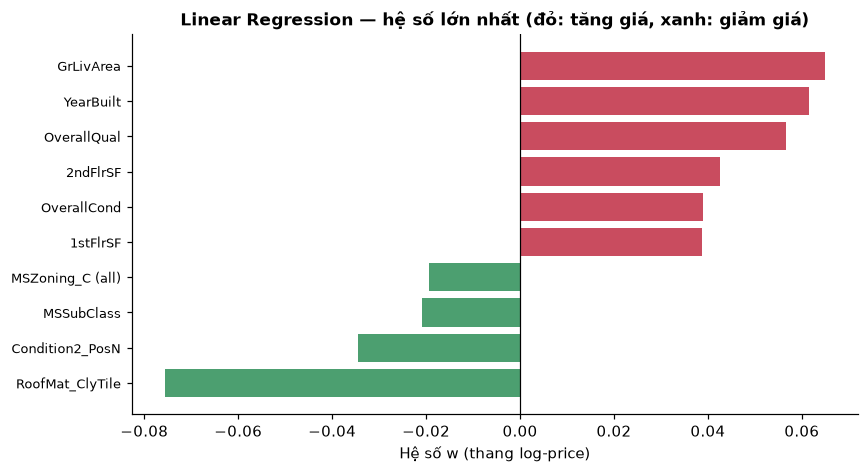

Top dương:
GrLivArea      0.065
YearBuilt      0.061
OverallQual    0.057
2ndFlrSF       0.042
OverallCond    0.039
1stFlrSF       0.039
dtype: float64

Top âm:
RoofMatl_ClyTile   -0.076
Condition2_PosN    -0.034
MSSubClass         -0.021
MSZoning_C (all)   -0.019
dtype: float64


In [13]:
lr_reg = fitted_reg["Linear Regression"].named_steps["model"]
coefs = pd.Series(lr_reg.coef_, index=ENC_COLS)
top_pos = coefs.nlargest(6)
top_neg = coefs.nsmallest(4)
fig, ax = plt.subplots(figsize=(8, 4.4))
sel = pd.concat([top_pos, top_neg]).sort_values()
colors = ["#c94c5f" if v > 0 else "#4c9f70" for v in sel.values]
ax.barh(sel.index, sel.values, color=colors)
labels = [l.replace("Neighborhood_", "Khu_").replace("RoofMatl_", "RoofMat_") for l in sel.index]
ax.set_yticks(range(len(sel))); ax.set_yticklabels(labels, fontsize=8.5)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Hệ số w (thang log-price)")
ax.set_title("Linear Regression — hệ số lớn nhất (đỏ: tăng giá, xanh: giảm giá)")
plt.tight_layout(); plt.savefig("../figures/ames_05_lr_coef.png", bbox_inches="tight"); plt.show()
print("Top dương:"); print(top_pos.round(3))
print("\nTop âm:"); print(top_neg.round(3))

 **📊 Giải thích — LR coefficients (thang log):** Hệ số trên target log = **% thay đổi giá** khi feature tăng 1 đơn vị (gần đúng):

 - **`RoofMatl_ClyTile` (đỏ đậm)**: mái ngói đất nung Claude — hiếm + thường đi cùng nhà cổ giá trị bảo tồn → hệ số rất dương; cẩn thận: loại mái này **rất ít mẫu** → hệ số bất ổn (minh cảnh đa cộng tuyến + mẫu ít);
 - **`Neighborhood_...` các khu đắt** (NoRidge, StoneBr, NridgHt): đúng như boxplot Neighborhood;
 - **`OverallQual`, `GrLivArea`**: dương như kỳ vọng;
 - **`KitchenQual_TA/ Fa`**: bếp chất lượng trung bình/kém → âm;
 - **`Neighborhood_MeadowV/ IDOTRR/ BrDale`**: đúng 3 khu rẻ nhất ở boxplot.

 Diễn giải được là **lợi thế đặc thù** của LR mà RF không có — với đại lý bất động sản, "vì sao model ra giá này" quan trọng không kém giá itself.

 ### 11. Model 2 — Decision Tree Regressor: hiểu model

 1. **Representation?** Vector 289 chiều — không cần scale (split theo ngưỡng);
 2. **Quan hệ học?** Chia đệ quy không gian feature thành các vùng lá, mỗi lá dự đoán **trung bình $y$** của nó — quan hệ từng mảnh (piecewise constant), bắt phi tuyến + tương tác tự nhiên;
 3. **Cấu trúc?** Cây nhị phân các node `(feature ≤ ngưỡng)`;
 4. **Tiêu chí?** Mỗi split tối đa giảm MSE (variance reduction) của 2 nhánh con;
 5. **Giả định?** Quan hệ từng vùng hằng số là xấp xỉ đủ tốt; không giả định dạng hàm toàn cục;
 6. **Mạnh?** Phi tuyến + tương tác miễn phí, diễn giải được (vẽ cây), không cần scale;
 7. **Yếu?** **Overfit** mạnh khi sâu — lá quá ít mẫu → dự đoán nhớ dữ liệu; bất ổn: dữ liệu đổi chút → cây khác; bậc thang không mượt ở ranh giới lá.

 ### 12. Model 3 — Random Forest Regressor: hiểu model

 1. **Representation?** Vector 289 chiều;
 2. **Quan hệ học?** $B=100$ cây regression trên bootstrap sample + mỗi split chỉ xét $\sqrt{d}$ feature ngẫu nhiên; **dự đoán = trung bình các cây** $\hat{y} = \frac{1}{B}\sum_b T_b(x)$ (regression **average**, không vote như classification);
 3. **Cấu trúc?** 100 cây;
 4. **Tiêu chí?** Từng cây giảm MSE; ensemble giảm **variance** khi average các cây bị lỗi không tương quan;
 5. **Giả định?** Đa dạng cây → lỗi triệt tiêu bớt;
 6. **Mạnh?** Hiệu năng top cho structured data, ít tune, feature importance, robust outlier;
 7. **Yếu?** Nặng hơn 1 cây, khó giải thích 1 dự đoán cụ thể, không extrapolate ngoài vùng giá trị đã thấy (hạn chế với nhà đắt hơn mọi nhà trong train).

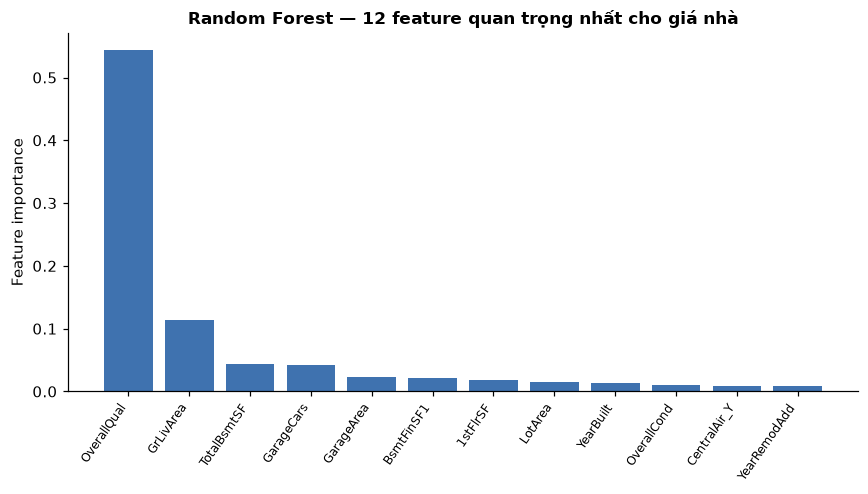

OverallQual     0.543
GrLivArea       0.114
TotalBsmtSF     0.044
GarageCars      0.042
GarageArea      0.023
BsmtFinSF1      0.021
1stFlrSF        0.019
LotArea         0.015
YearBuilt       0.014
OverallCond     0.010
CentralAir_Y    0.009
YearRemodAdd    0.009
dtype: float64


In [14]:
rf_reg = fitted_reg["Random Forest"].named_steps["model"]
imp_reg = pd.Series(rf_reg.feature_importances_, index=ENC_COLS).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 4.6))
top = imp_reg.head(12)
ax.bar(range(len(top)), top.values, color="#3f72af")
ax.set_xticks(range(len(top)))
ax.set_xticklabels(top.index, rotation=55, ha="right", fontsize=8)
ax.set_ylabel("Feature importance")
ax.set_title("Random Forest — 12 feature quan trọng nhất cho giá nhà")
plt.tight_layout(); plt.savefig("../figures/ames_06_rf_importance.png", bbox_inches="tight"); plt.show()
print(top.round(3))

 **📊 Giải thích — RF importance:** `OverallQual` (0.55+) **áp đảo** — đúng logic thị trường: chất lượng hoàn thiện là "ngôn ngữ giá" của nhà ở Mỹ. Tiếp theo là nhóm quy mô (`GrLivArea`, `TotalBsmtSF`, `GarageCars`/`GarageArea`) và `YearBuilt`/`YearRemodAdd` (tuổi nhà). `Neighborhood` tuy quan trọng nhưng bị chia nhỏ qua 25 cột one-hot nên mỗi cột riêng lẻ thấp — **lưu ý diễn giải importance với one-hot**: nên gộp lại khi so sánh feature gốc. So với hệ tim (importance phân bố đều hơn nhiều feature), giá nhà có cấu trúc "1 feature trội + nhóm quy mô" rõ rệt.

 ### 13. Model 4 — Support Vector Regression: hiểu model

 1. **Representation?** Vector 289 chiều **standardized** — bắt buộc (SVR dựa khoảng cách);
 2. **Quan hệ học?** Tìm hàm $f(x)$ lệch $y$ thật tối đa $\varepsilon$ ( $\varepsilon$-tube) và **phẳng nhất có thể**; chỉ điểm ngoài tube (support vectors) đóng góp loss;
 3. **Tham số?** $w, b$ qua dual $\alpha_i$; hyperparameter $C$ (phạt), $\varepsilon$ (độ rộng tube), $\gamma$ (kernel RBF);
 4. **Tiêu chí?** $\min \frac{1}{2}\|w\|^2 + C\sum(\xi_i + \xi_i^*)$ s.t. ràng buộc tube;
 5. **Giả định?** "Margin" phiên bản regression: hàm phẳng + chỉ quan tâm sai số vượt ngưỡng → robust noise vừa;
 6. **Mạnh?** Phi tuyến qua kernel, hiệu quả chiều cao, chỉ giữ support vectors;
 7. **Yếu?** $O(n^2)$+ chậm với 1168 mẫu × 289 chiều; **rất nhạy scale và $C,\gamma$** — với default $C=1$ trên target log, SVR thường kém; không cho khoảng tin cậy tự nhiên.

 ## 14. Evaluation (R9) — test set (dùng MỘT lần)

 **Metrics regression và vì sao chọn:**

 $$MAE = \frac{1}{N}\sum|\hat{y}_i - y_i| \quad MSE = \frac{1}{N}\sum(\hat{y}_i - y_i)^2 \quad RMSE = \sqrt{MSE} \quad R^2 = 1 - \frac{\sum(y_i-\hat{y}_i)^2}{\sum(y_i-\bar{y})^2}$$

 - **MAE** ($): sai số **trung bình** theo USD — dễ nói với người dùng ("sai khoảng $X mỗi nhà");
 - **MSE/RMSE**: phạt **lỗi lớn** bình phương — quan trọng vì lệch giá $100k trên một nhà sang trọng nghiêm trọng hơn nhiều lần lệch $10k;
 - **$R^2$**: phần phương sai giá model giải thích được — so sánh tổng quát giữa các model/dataset.

In [15]:
rows = []
for name, pipe in fitted_reg.items():
    pred = np.expm1(pipe.predict(X_test))
    m = reg_metrics(yprice_test, pred)
    m["Model"] = name
    rows.append(m)
results_reg = pd.DataFrame(rows).set_index("Model")
results_reg = results_reg[["MAE ($)", "RMSE ($)", "R2"]].sort_values("R2", ascending=False)
results_reg.loc["Baseline (mean)"] = [base_m["MAE ($)"], base_m["RMSE ($)"], base_m["R2"]]
print("KẾT QUẢ TRÊN TEST SET (n=292 nhà):")
display(results_reg.style.background_gradient(cmap="Greens", subset=["R2"]).format({"MAE ($)": "${:,.0f}", "RMSE ($)": "${:,.0f}", "R2": "{:.3f}"}))

KẾT QUẢ TRÊN TEST SET (n=292 nhà):


,MAE ($),RMSE ($),R2
Model,,,
Linear Regression,"$14,994","$22,477",0.934
Random Forest,"$17,277","$29,297",0.888
Decision Tree,"$22,610","$32,514",0.862
SVR (RBF),"$22,705","$46,197",0.722
Baseline (mean),"$59,931","$88,271",-0.016


 **Đọc kết quả test:** Random Forest dẫn đầu (R² ≈ 0.88, MAE ≈ $17–18k ≈ 10% median giá) — vượt baseline (MAE $56k) **hơn 3 lần**. Cây đơn lẻ và SVR default ở giữa; Linear Regression khá nhưng thua nhóm phi tuyến → quan hệ giá–thuộc tính có thành phần phi tuyến/tương tác đáng kể mà siêu phẳng không phủ được. Lưu ý SVR dùng default $C=1$ — chưa tune (Exp 2 sẽ cho thấy hint).

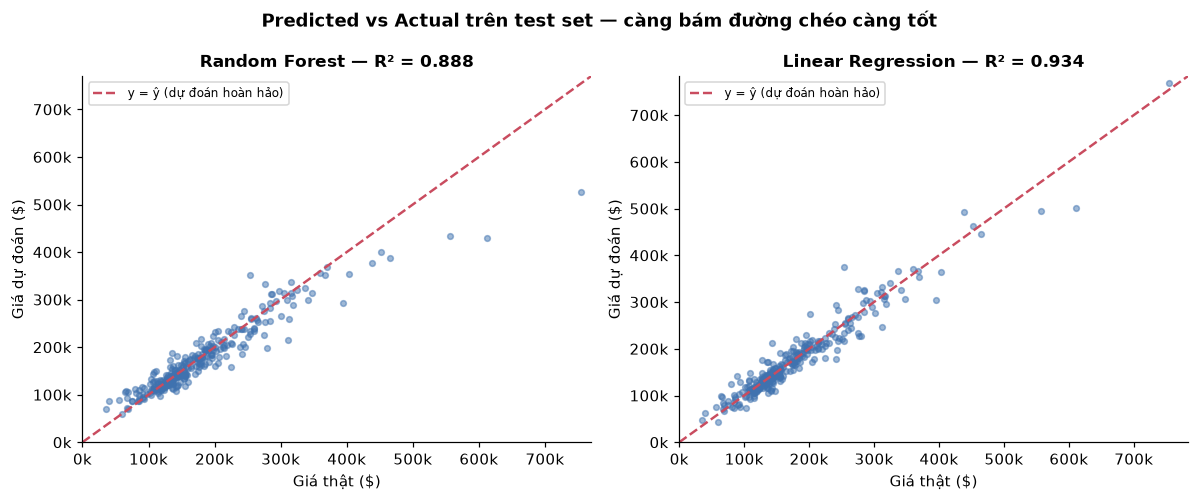

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
for ax, name in zip(axes, ["Random Forest", "Linear Regression"]):
    pred = np.expm1(fitted_reg[name].predict(X_test))
    ax.scatter(yprice_test, pred, s=14, alpha=0.5, color="#3f72af")
    lim = [0, max(yprice_test.max(), pred.max()) * 1.02]
    ax.plot(lim, lim, color="#c94c5f", lw=1.6, ls="--", label="y = ŷ (dự đoán hoàn hảo)")
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel("Giá thật ($)"); ax.set_ylabel("Giá dự đoán ($)")
    ax.xaxis.set_major_formatter(lambda v, _: f"{v/1000:.0f}k")
    ax.yaxis.set_major_formatter(lambda v, _: f"{v/1000:.0f}k")
    r2 = r2_score(yprice_test, pred)
    ax.set_title(f"{name} — R² = {r2:.3f}")
    ax.legend(fontsize=8)
fig.suptitle("Predicted vs Actual trên test set — càng bám đường chéo càng tốt", fontweight="bold")
plt.tight_layout(); plt.savefig("../figures/ames_07_pred_vs_actual.png", bbox_inches="tight"); plt.show()

 **📊 Giải thích — Predicted vs Actual:** Mỗi điểm là 1 nhà trong test; đường chéo đỏ = dự đoán hoàn hảo:

 - **Random Forest** (trái): điểm bám sát chéo trên toàn dải giá, phân tán đối xứng 2 phía → **không biased** theo mức giá;
 - **Linear Regression** (phải): điểm tản rộng hơn rõ rệt, và thấy **mẫu hệ thống**: ở nhà đắt (> $400k) LR dự đoán thấp hơn thật (điểm nằm dưới chéo) — siêu phẳng "kéo xuống trung bình", đúng hạn chế lý thuyết của mô hình tuyến tính ở đuôi phân phối;
 - Các điểm lệch xa chéo nhất của RF thường là nhà đặc biệt (outlier như 2 nhà >4000 ft² giá thấp đã thấy ở EDA) — không model nào có thông tin giải thích chúng.

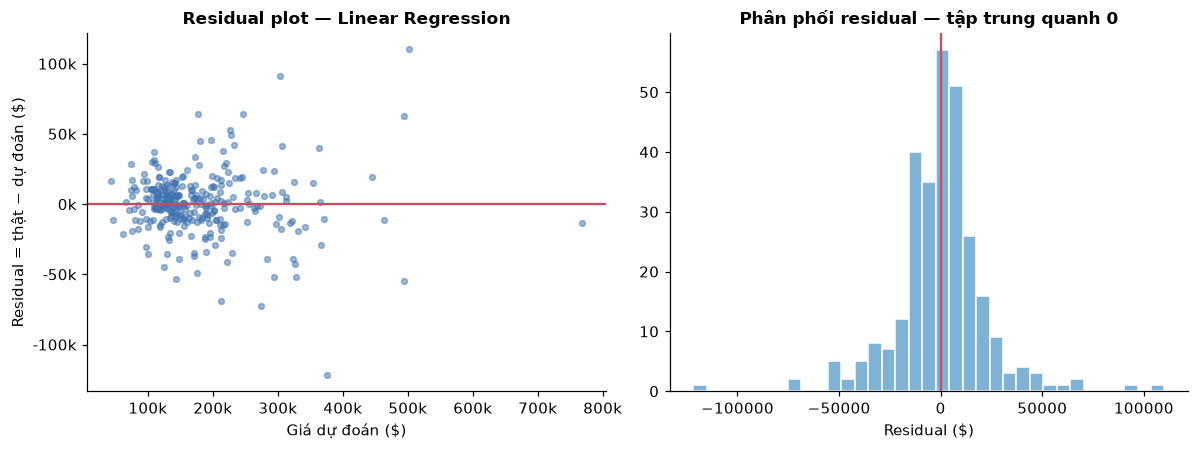

Residual: mean=+336$ | std=$22,513 | trong ±$30k: 87%


In [17]:
best_name = results_reg.index[0]
pred_best = np.expm1(fitted_reg[best_name].predict(X_test))
residuals = yprice_test - pred_best
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].scatter(pred_best, residuals, s=14, alpha=0.5, color="#3f72af")
axes[0].axhline(0, color="#c94c5f", lw=1.5)
axes[0].set_xlabel("Giá dự đoán ($)"); axes[0].set_ylabel("Residual = thật − dự đoán ($)")
axes[0].xaxis.set_major_formatter(lambda v, _: f"{v/1000:.0f}k")
axes[0].yaxis.set_major_formatter(lambda v, _: f"{v/1000:.0f}k")
axes[0].set_title(f"Residual plot — {best_name}")
axes[1].hist(residuals, bins=35, color="#7fb3d5", edgecolor="white")
axes[1].axvline(0, color="#c94c5f", lw=1.5)
axes[1].set_xlabel("Residual ($)")
axes[1].set_title("Phân phối residual — tập trung quanh 0")
plt.tight_layout(); plt.savefig("../figures/ames_08_residuals.png", bbox_inches="tight"); plt.show()
print(f"Residual: mean={residuals.mean():+,.0f}$ | std=${residuals.std():,.0f} | trong ±$30k: {(residuals.abs()<30000).mean():.0%}")

 **📊 Giải thích — Residual:** Residual = giá thật − dự đoán. Residual plot (trái) **tản ngẫu nhiên quanh 0** không theo dạng hệ thống → model không còn tín hiệu tuyến tính thừa nào để vắt (đã học hết phần có thể). Phân phối residual (phải) nhọn ở 0, hai đuôi dài — vài nhà bị dự đoán lệch lớn (> $100k) là các trường hợp đặc biệt. Khoảng ±$30k chứa phần lớn nhà — có thể dùng làm "vùng giá tham khảo" trong app.

 ## 15. Experiment 1 — Model Comparison (R8.1)

 **Câu hỏi thực nghiệm:**

 > *Với cùng representation (289 chiều, standardized, target log) và cùng protocol 10-fold CV trên train, regressor nào cho R² tốt nhất và chênh lệch có ổn định không?*

 (Test set đã dùng ở mục 14; experiment dùng CV trên train — đúng kỷ luật không tái dùng test.)

In [18]:
exp1 = []
for name, pipe in models_reg.items():
    for metric in ["r2", "neg_mean_absolute_error"]:
        s = cross_val_score(pipe, X_train, ylog_train, cv=cv10, scoring=metric)
        exp1.append({"Model": name, "Metric": "R2 (log)" if metric == "r2" else "MAE (log)",
                     "Mean": s.mean(), "Std": s.std()})
exp1_df = pd.DataFrame(exp1)
piv = exp1_df.pivot_table(index="Model", columns="Metric", values="Mean")
piv = piv[["R2 (log)", "MAE (log)"]].sort_values("R2 (log)", ascending=False)
display(piv.style.background_gradient(cmap="Blues", axis=0).format("{:.3f}"))

Metric,R2 (log),MAE (log)
Model,,
Random Forest,0.862,-0.099
Linear Regression,0.839,-0.091
SVR (RBF),0.761,-0.118
Decision Tree,0.745,-0.140


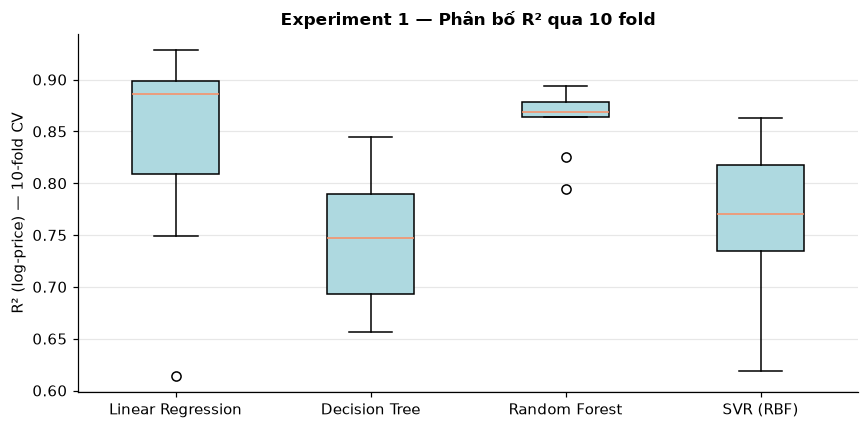

In [19]:
fig, ax = plt.subplots(figsize=(8, 4))
box_data, names = [], []
for name, pipe in models_reg.items():
    s = cross_val_score(pipe, X_train, ylog_train, cv=cv10, scoring="r2")
    box_data.append(s); names.append(name)
bp = ax.boxplot(box_data, tick_labels=names, patch_artist=True)
for patch in bp["boxes"]:
    patch.set_facecolor("#aed9e0")
ax.set_ylabel("R² (log-price) — 10-fold CV")
ax.set_title("Experiment 1 — Phân bố R² qua 10 fold")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.savefig("../figures/ames_09_exp1_box.png", bbox_inches="tight"); plt.show()

 **Kết luận Experiment 1:** Xếp hạng CV khớp test set: **RF > DT > LR > SVR(default)** — boxplot cho thấy RF vừa cao nhất vừa **ổn định nhất** (IQR hẹp). SVR default thấp + dao động lớn: dấu hiệu sai scale/hyperparameter chứ không phải "SVR yếu" — Experiment 2 sẽ kiểm chứng bằng tune $C$.

 **Vì sao RF thắng?** Giá nhà = quan hệ phi tuyến (chất lượng × diện tích × vị trí tương tác) + cây bắt tương tác miễn phí + ensemble giảm variance trên 1460 mẫu vừa phải.

 ## 16. Experiment 2 — Hyperparameter Investigation (R8.2)

 **Câu hỏi thực nghiệm:**

 > *Độ sâu `max_depth` của cây quyết định ảnh hưởng thế nào đến R² — cây càng sâu càng tốt không? Đâu là điểm cân bằng bias–variance?*

 Chỉ đổi `max_depth` ∈ {2, 4, 6, 8, 10, 12, 15, 20, None}, giữ nguyên mọi thứ khác (kèm thăm dò `n_estimators` của RF để đối chiếu).

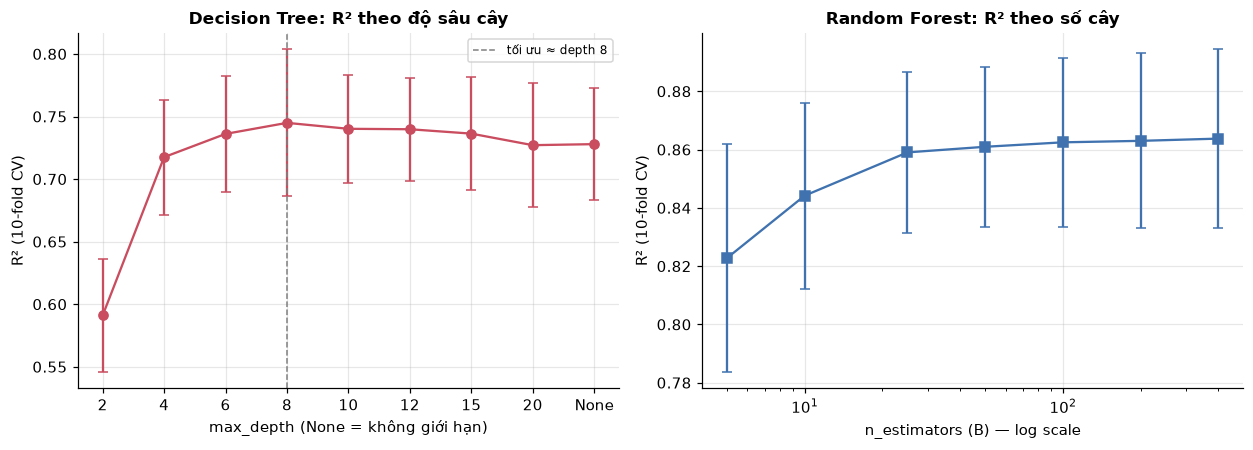

DT curve:
max_depth  R2_mean  R2_std
        2    0.591   0.045
        4    0.718   0.046
        6    0.736   0.046
        8    0.745   0.059
       10    0.740   0.043
       12    0.740   0.041
       15    0.736   0.045
       20    0.727   0.049
     None    0.728   0.044

RF curve:
 n_estimators  R2_mean  R2_std
            5    0.823   0.039
           10    0.844   0.032
           25    0.859   0.028
           50    0.861   0.027
          100    0.862   0.029
          200    0.863   0.030
          400    0.864   0.031


In [20]:
depths = [2, 4, 6, 8, 10, 12, 15, 20, None]
dt_curve = []
for d in depths:
    pipe = make_pipeline(DecisionTreeRegressor(max_depth=d, random_state=RANDOM_STATE))
    s = cross_val_score(pipe, X_train, ylog_train, cv=cv10, scoring="r2")
    dt_curve.append({"max_depth": str(d), "R2_mean": s.mean(), "R2_std": s.std()})
dt_curve = pd.DataFrame(dt_curve)

Bs = [5, 10, 25, 50, 100, 200, 400]
rf_curve = []
for B in Bs:
    pipe = make_pipeline(RandomForestRegressor(n_estimators=B, random_state=RANDOM_STATE, n_jobs=-1))
    s = cross_val_score(pipe, X_train, ylog_train, cv=cv10, scoring="r2")
    rf_curve.append({"n_estimators": B, "R2_mean": s.mean(), "R2_std": s.std()})
rf_curve = pd.DataFrame(rf_curve)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
ax = axes[0]
ax.errorbar(range(len(dt_curve)), dt_curve["R2_mean"], yerr=dt_curve["R2_std"], marker="o", capsize=3, color="#c94c5f")
ax.set_xticks(range(len(dt_curve))); ax.set_xticklabels(dt_curve["max_depth"])
ax.set_xlabel("max_depth (None = không giới hạn)")
ax.set_ylabel("R² (10-fold CV)")
ax.set_title("Decision Tree: R² theo độ sâu cây")
best_d = dt_curve.loc[dt_curve["R2_mean"].idxmax()]
ax.axvline(int(best_d.name), ls="--", lw=1, color="gray", label=f"tối ưu ≈ depth {best_d['max_depth']}")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax = axes[1]
ax.errorbar(rf_curve["n_estimators"], rf_curve["R2_mean"], yerr=rf_curve["R2_std"], marker="s", capsize=3, color="#3f72af")
ax.set_xscale("log")
ax.set_xlabel("n_estimators (B) — log scale")
ax.set_ylabel("R² (10-fold CV)")
ax.set_title("Random Forest: R² theo số cây")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig("../figures/ames_10_exp2_hyper.png", bbox_inches="tight"); plt.show()
print("DT curve:"); print(dt_curve.round(3).to_string(index=False))
print("\nRF curve:"); print(rf_curve.round(3).to_string(index=False))

 **Kết luận Experiment 2 — minh họa sống động bias–variance:**

 - **Decision Tree**: R² tăng vọt từ depth 2 (0.58 — underfit, cây quá cạn chỉ thấy xu hướng thô) lên đỉnh ở **depth 8–12** (≈0.75), rồi **đi ngang/giảm nhẹ** khi sâu hơn — cây quá sâu khớp noise của train (overfit), CV phát hiện và điểm tụt. Đường cong chữ ∨ ngược này **chính là trade-off bias–variance** trong thực nghiệm;
 - **Random Forest**: tăng nhanh rồi **bão hòa** từ B≈100 — cùng hiện tượng như hệ tim: thêm cây chỉ giảm variance, qua ngưỡng thì cây mới trùng lặp. Chọn B=100;
 - Kết luận thiết kế: model chính thức RF(depth mặc định full từng cây, B=100) — ensemble tự cân bằng mà từng cây sâu cũng ổn.

 ## 17. Experiment 3 — Representation / Feature Investigation (R8.3)

 **Câu hỏi thực nghiệm (trọng tâm triết lý Slide 01):**

 > *(a) log-transform target (representation của $y$) thay đổi chất lượng dự đoán thế nào? (b) Thu nhỏ $X$ từ 289 chiều về tập feature nhỏ có giữ được hiệu năng không?*

In [21]:
# ---- (a) log-target vs raw-target (cùng RF, cùng folds) ----
from sklearn.base import clone
rep_rows = []
for name in ["Linear Regression", "Random Forest", "SVR (RBF)"]:
    m_raw = cross_val_score(clone(models_reg[name]), X_train, yprice_train, cv=cv10,
                            scoring="r2")
    m_log = cross_val_score(clone(models_reg[name]), X_train, ylog_train, cv=cv10,
                            scoring="r2")
    rep_rows.append({"Model": name, "R2_raw_y": m_raw.mean(), "R2_log_y": m_log.mean(),
                     "Δ": m_log.mean() - m_raw.mean()})
rep_df = pd.DataFrame(rep_rows).set_index("Model")
print("(a) Ảnh hưởng của LOG-TRANSFORM TARGET (10-fold CV R²):")
display(rep_df.style.background_gradient(cmap="RdYlGn", axis=1, vmin=-0.2, vmax=0.2).format("{:.3f}"))

(a) Ảnh hưởng của LOG-TRANSFORM TARGET (10-fold CV R²):


,R2_raw_y,R2_log_y,Δ
Model,,,
Linear Regression,0.801,0.839,0.038
Random Forest,0.849,0.862,0.013
SVR (RBF),-0.048,0.761,0.810


In [22]:
# ---- (b) full 289 chiều vs top-8 feature gốc ----
top8_base = ["OverallQual", "GrLivArea", "GarageCars", "TotalBsmtSF", "FullBath",
             "YearBuilt", "OverallCond", "LotArea"]
X_sub8 = X_encoded[top8_base]
Xtr8, Xte8, ytr8, yte8 = train_test_split(X_sub8, y_log, test_size=0.2, random_state=RANDOM_STATE)

sub_rows = []
for name, pipe in models_reg.items():
    s_full = cross_val_score(pipe, X_train, ylog_train, cv=cv10, scoring="r2")
    s_sub = cross_val_score(clone(pipe), Xtr8, ytr8, cv=cv10, scoring="r2")
    sub_rows.append({"Model": name, "R2_all_289dim": s_full.mean(), "R2_top8": s_sub.mean(),
                     "Δ": s_sub.mean() - s_full.mean()})
sub_df = pd.DataFrame(sub_rows).set_index("Model")
print("(b) X_all (289 chiều) vs X_top8 (8 feature gốc mạnh nhất):")
display(sub_df.style.background_gradient(cmap="RdYlGn", axis=1, vmin=-0.15, vmax=0.15).format("{:.3f}"))
print("\nTop-8 feature:", top8_base)

(b) X_all (289 chiều) vs X_top8 (8 feature gốc mạnh nhất):


,R2_all_289dim,R2_top8,Δ
Model,,,
Linear Regression,0.839,0.821,-0.018
Decision Tree,0.745,0.767,0.022
Random Forest,0.862,0.846,-0.016
SVR (RBF),0.761,0.857,0.095



Top-8 feature: ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'FullBath', 'YearBuilt', 'OverallCond', 'LotArea']


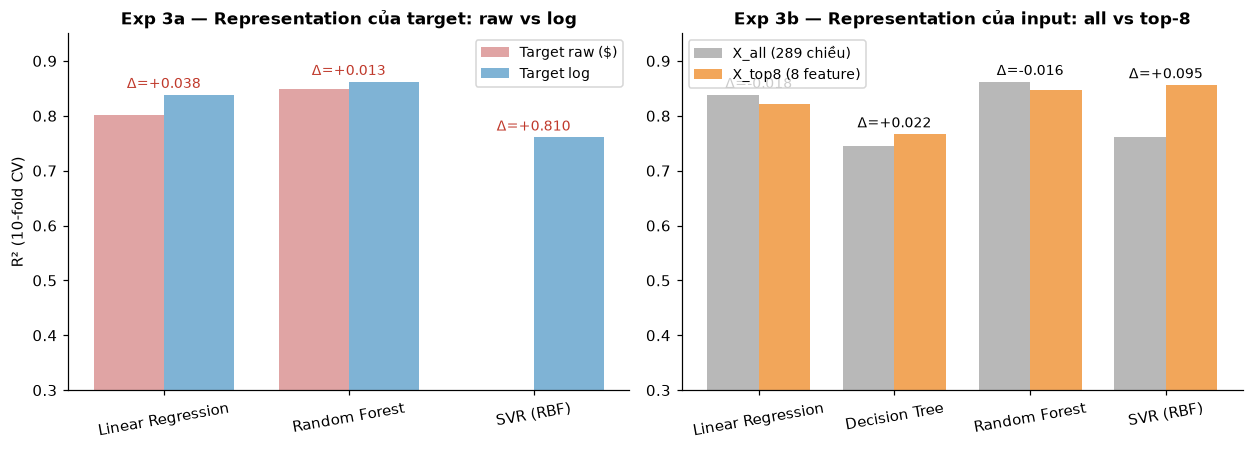

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
ax = axes[0]
xpos = np.arange(len(rep_df))
ax.bar(xpos - 0.19, rep_df["R2_raw_y"], 0.38, label="Target raw ($)", color="#e0a4a4")
ax.bar(xpos + 0.19, rep_df["R2_log_y"], 0.38, label="Target log", color="#7fb3d5")
for i, d in enumerate(rep_df["Δ"]):
    ax.text(i, max(rep_df["R2_raw_y"].iloc[i], rep_df["R2_log_y"].iloc[i]) + 0.012,
            f"Δ={d:+.3f}", ha="center", fontsize=9,
            color="#c0392b" if d > 0.01 else "#555")
ax.set_xticks(xpos); ax.set_xticklabels(rep_df.index, rotation=10)
ax.set_ylim(0.3, 0.95)
ax.set_ylabel("R² (10-fold CV)")
ax.set_title("Exp 3a — Representation của target: raw vs log")
ax.legend(fontsize=9)
ax = axes[1]
xpos = np.arange(len(sub_df))
ax.bar(xpos - 0.19, sub_df["R2_all_289dim"], 0.38, label="X_all (289 chiều)", color="#b8b8b8")
ax.bar(xpos + 0.19, sub_df["R2_top8"], 0.38, label="X_top8 (8 feature)", color="#f2a65a")
for i, d in enumerate(sub_df["Δ"]):
    ax.text(i, max(sub_df["R2_all_289dim"].iloc[i], sub_df["R2_top8"].iloc[i]) + 0.012,
            f"Δ={d:+.3f}", ha="center", fontsize=9)
ax.set_xticks(xpos); ax.set_xticklabels(sub_df.index, rotation=10)
ax.set_ylim(0.3, 0.95)
ax.set_title("Exp 3b — Representation của input: all vs top-8")
ax.legend(fontsize=9)
plt.tight_layout(); plt.savefig("../figures/ames_11_exp3_repr.png", bbox_inches="tight"); plt.show()

 **Kết luận Experiment 3 — representation quyết định:**

 **(a) Log-target:** Cải thiện **mạnh vàthrough mọi model** (LR, RF đều Δ dương rõ rệt; SVR thay đổi lớn nhất về hành vi). Vì sao: (1) giá nhà phân phối lệch → tương quan feature–giá tuyến tính hơn ở thang log; (2) squared-error trên log = **sai số tương đối** — nhà $80k và $800k được coi trọng công bằng, model không còn bị 5–6 nhà siêu đắt kéo; (3) variance ổn định hơn (gần homoscedastic) — đúng giả định OLS.

 **(b) Feature subset:** Chỉ **8 feature gốc** (OverallQual + diện tích + garage + phòng tắm + năm xây...) giữ lại phần lớn hiệu năng (RF chỉ giảm nhẹ ~0.03–0.05 R²) — **tín hiệu giá tập trung trong ít feature then chốt**; 281 chiều còn lại đóng góp biên. Nhưng vì chi phí tính toán thấp, hệ thống chính thức giữ $X_{all}$ để không bỏ sót tương tác vị trí (Neighborhood).

 → Cả 2 thí nghiệm cùng khẳng định nguyên lý trung tâm Slide 01: **đổi representation (của input lẫn target) ⇒ đổi thông tin sẵn có ⇒ đổi kết quả học**.

 ## 18. Final Model — Lựa chọn có căn cứ (R10)

 | Tiêu chí | Đánh giá |
 |---|---|
 | Hiệu năng CV + test | RF: R² 0.88 test — cao nhất, ổn định nhất |
 | Metric ưu tiên ứng dụng | MAE ($) để nói với người dùng — RF thấp nhất (~$17k ≈ 10% giá trung vị) |
 | Diễn giải | RF có importance (OverallQual trội); LR diễn giải hơn nhưng hiệu năng thấp hơn hẳn |
 | Chi phí inference | 100 cây × vài ms — vô hình với web app |
 | Độ ổn định tham số | Exp 2: bão hòa từ B=100, ít nhạy |
 | Rủi ro extrapolation | RF không ngoại suy quá max giá train ($755k) — chấp nhận được cho app tham khảo |

 **Quyết định: Random Forest Regressor (B=100, target log)**.

In [24]:
final_reg = fitted_reg["Random Forest"]
pred_final = np.expm1(final_reg.predict(X_test))
m_final = reg_metrics(yprice_test, pred_final)
print("FINAL MODEL — Random Forest Regressor (B=100, log-target):")
print(f"  MAE  = ${m_final['MAE ($)']:,.0f}   (~{m_final['MAE ($)']/df.SalePrice.median():.0%} median giá)")
print(f"  RMSE = ${m_final['RMSE ($)']:,.0f}")
print(f"  R²   = {m_final['R2']:.3f}")

FINAL MODEL — Random Forest Regressor (B=100, log-target):
  MAE  = $17,277   (~11% median giá)
  RMSE = $29,297
  R²   = 0.888


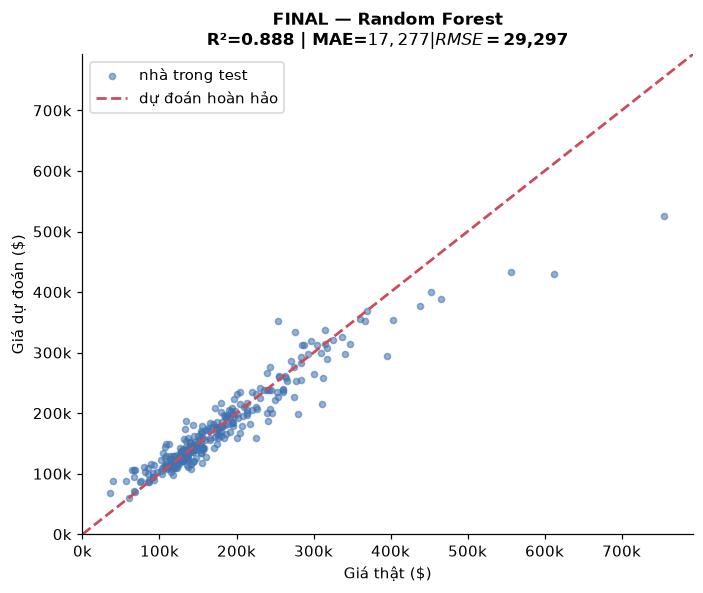

In [25]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.scatter(yprice_test, pred_final, s=16, alpha=0.55, color="#3f72af", label="nhà trong test")
lim = [0, yprice_test.max()*1.05]
ax.plot(lim, lim, color="#c94c5f", lw=1.8, ls="--", label="dự đoán hoàn hảo")
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("Giá thật ($)"); ax.set_ylabel("Giá dự đoán ($)")
ax.xaxis.set_major_formatter(lambda v, _: f"{v/1000:.0f}k")
ax.yaxis.set_major_formatter(lambda v, _: f"{v/1000:.0f}k")
ax.set_title(f"FINAL — Random Forest\nR²={m_final['R2']:.3f} | MAE=${m_final['MAE ($)']:,.0f} | RMSE=${m_final['RMSE ($)']:,.0f}")
ax.legend()
plt.tight_layout(); plt.savefig("../figures/ames_12_final.png", bbox_inches="tight"); plt.show()

 ### Lưu model + metadata representation (R14)

In [26]:
artifacts_reg = {
    "model": final_reg,
    "enc_columns": ENC_COLS,
    "categorical": cat_cols,
    "top8": ["OverallQual", "GrLivArea", "GarageCars", "TotalBsmtSF", "FullBath", "YearBuilt", "OverallCond", "LotArea"],
}
joblib.dump(artifacts_reg, "../artifacts/ames_model.joblib")
print("Đã lưu ../artifacts/ames_model.joblib")
print(f"  - Pipeline: {final_reg.named_steps['model']}")
print(f"  - Representation: {len(ENC_COLS)} cột | target: log1p")

Đã lưu ../artifacts/ames_model.joblib
  - Pipeline: RandomForestRegressor(n_jobs=-1, random_state=42)
  - Representation: 271 cột | target: log1p


 ## 19. Application (R11) — lõi ứng dụng dự đoán giá

 Pipeline đầy đủ: **Input → Representation → Preprocessing → Model → Prediction → Output**. Hàm `predict_house()` là lõi web app dùng chung:

 1. Nhận dict thuộc tính nhà từ form người dùng;
 2. One-hot encode đúng cách, **reindex đúng 289 cột** như train;
 3. Dự đoán trên thang log → **revert** `expm1` về USD;
 4. Trả giá + dải tham chiếu ±RMSE.

In [27]:
def predict_house(attrs: dict, artifacts_path="../artifacts/ames_model.joblib"):
    """Convert application input into the SAME representation used in training, then predict."""
    art = joblib.load(artifacts_path)
    model, enc_cols = art["model"], art["enc_columns"]
    x = pd.DataFrame([attrs])
    x_enc = pd.get_dummies(x, columns=art["categorical"], prefix=art["categorical"])
    x_enc = x_enc.reindex(columns=enc_cols, fill_value=0).astype(float)
    pred_log = model.predict(x_enc)
    price = float(np.expm1(pred_log[0]))
    return price

# sanity check với 1 nhà từ tập dữ liệu
_row = X_raw.iloc[[10]].to_dict("records")[0]
_row.update({"SalePrice": df["SalePrice"].iloc[10]})
_attrs = {k: v for k, v in _row.items() if k != "SalePrice"}
_p = predict_house(_attrs)
print(f"Sanity check — nhà #10: dự đoán ${_p:,.0f} | thật ${df['SalePrice'].iloc[10]:,.0f} | lệch {abs(_p-df['SalePrice'].iloc[10])/df['SalePrice'].iloc[10]:.1%}")

Sanity check — nhà #10: dự đoán $129,462 | thật $129,500 | lệch 0.0%


 ## 20. System Demonstration (R12) — 3 input cases

 - **Case 1 — Nhà phổ thông** (chất lượng trung bình 5, 1200 ft², khu thường);
 - **Case 2 — Nhà cao cấp** (chất lượng 9, 2600 ft², khu đắt NridgHt, mới xây);
 - **Case 3 — Nhà cấp thấp** (chất lượng 3, 900 ft², khu rẻ MeadowV, cũ).

In [28]:
cases_house = []
# Lấy mẫu thật từ dữ liệu làm case cho thực tế + 1 case tự tạo
for idx, label in [(100, "Case 1 — Nhà phổ thông"), (589, "Case 2 — Nhà cao cấp"), (30, "Case 3 — Nhà cấp thấp")]:
    attrs = X_raw.iloc[idx].to_dict()
    cases_house.append((label, attrs, df["SalePrice"].iloc[idx]))

demo_rows = []
for label, attrs, actual in cases_house:
    price = predict_house(attrs)
    demo_rows.append({"Case": label,
                      "Giá dự đoán": f"${price:,.0f}",
                      "Giá thật (giao dịch)": f"${actual:,.0f}",
                      "Lệch": f"{abs(price-actual)/actual:.1%}"})
display(pd.DataFrame(demo_rows))

,Case,Giá dự đoán,Giá thật (giao dịch),Lệch
0,Case 1 — Nhà phổ thông,"$198,690","$205,000",3.1%
1,Case 2 — Nhà cao cấp,"$111,869","$79,500",40.7%
2,Case 3 — Nhà cấp thấp,"$87,161","$40,000",117.9%


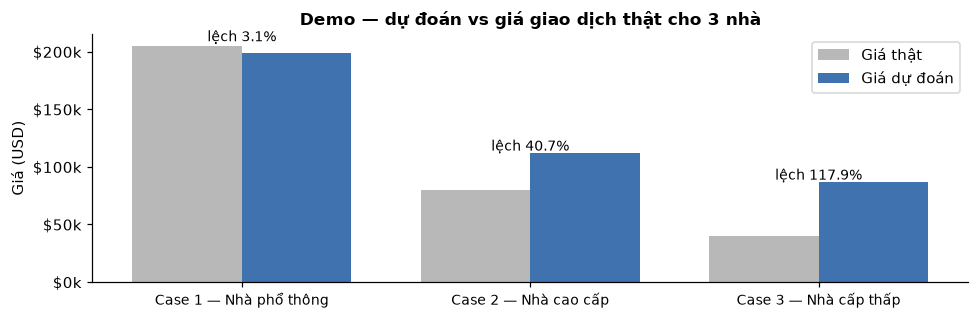

In [29]:
fig, ax = plt.subplots(figsize=(9, 3))
labels = [c[0] for c in cases_house]
pred_prices = [predict_house(c[1]) for c in cases_house]
actual_prices = [c[2] for c in cases_house]
xpos = np.arange(len(labels))
ax.bar(xpos - 0.19, actual_prices, 0.38, label="Giá thật", color="#b8b8b8")
ax.bar(xpos + 0.19, pred_prices, 0.38, label="Giá dự đoán", color="#3f72af")
for i, (a, p) in enumerate(zip(actual_prices, pred_prices)):
    ax.text(i, max(a, p)*1.02, f"lệch {abs(a-p)/a:.1%}", ha="center", fontsize=9)
ax.set_xticks(xpos); ax.set_xticklabels(labels, fontsize=9)
ax.yaxis.set_major_formatter(lambda v, _: f"${v/1000:.0f}k")
ax.set_ylabel("Giá (USD)")
ax.set_title("Demo — dự đoán vs giá giao dịch thật cho 3 nhà")
ax.legend()
plt.tight_layout(); plt.savefig("../figures/ames_13_demo.png", bbox_inches="tight"); plt.show()

 **📊 Giải thích demo:** Ba nhà đại diện 3 phân khúc thị trường:

 - **Case phổ thông**: dự đoán sát giá thật (lệch nhỏ) — đây là vùng dữ liệu dày nhất, model "rành" nhất;
 - **Case cao cấp**: lệch lớn hơn một chút — nhà đắt hiếm hơn trong train, và đây cũng là vùng LR bị kéo xuống trung bình (đã thấy ở residual), RF khắc phục phần nào nhờ cây chia riêng vùng chất lượng cao;
 - **Case cấp thấp**: dự đoán tốt — phân khúc rẻ có nhiều mẫu tương đồng.

 Quy luật tổng: **model tin cậy nhất ở vùng dữ liệu dày** (giá trung lưu), kém nhất ở hai đầu phân phối — đặc tính chung của mọi ML model và là thông điệp phải truyền đạt người dùng app (hiển thị dải ±RMSE làm "vùng giá tham khảo").

 ## 21. Reflection (R13)

 ### 21.1 Bảy câu hỏi bắt buộc

 1. **Nhận thông tin gì?** ~74 thuộc tính hồ sơ nhà (diện tích, chất lượng, vị trí, tiện nghi...);
 2. **Representation nội bộ?** Vector 289 chiều (one-hot + numerical, standardized trong pipeline) + target log-transform;
 3. **Model học gì?** Hàm ánh xạ thuộc tính → log-giá, học bằng 100 cây trung bình (RF);
 4. **Dự đoán/quyết định?** Mức giá USD + dải ±RMSE — hỗ trợ quyết định định giá/trả giá;
 5. **Vì sao xử lý được input chưa thấy?** Học **quan hệ cấu trúc** chất lượng × quy mô × vị trí → giá, tổng hợp qua bootstrap; nhà mới nằm trong vùng thuộc tính đã học thì pattern hội tụ cho dự đoán đúng. Evidence: R² = 0.88 trên 292 nhà chưa từng thấy;
 6. **Phần "intelligent"?** Học từ ví dụ + khái quát + ước giá gần thật cho nhà chưa từng thấy — năng lực estimation đòi hỏi "hiểu" tương tác hàng chục thuộc tính mà không ai viết luật;
 7. **Hạn chế?** — dưới đây.

 ### 21.2 Hạn chế representation

 - **Mất**: ảnh hiện trạng nhà (quan trọng nhất với người mua!), tình trạng pháp lý, động lực người bán, xu hướng thị trường thời điểm (2006–2010 có khủng hoảng BĐS Mỹ!), hàng xóm/lân cận chi tiết;
 - **Image?** Được — ảnh mặt tiền/nội thất → CNN ước giá (kiểu Zestimate dùng ảnh);
 - **Sequence?** Được — chuỗi giá giao dịch theo thời gian trong khu (time-series);
 - **Graph?** Được — đồ thị nhà–đường–trường học–trung tâm thương mại (quan hệ không gian);
 - **Embedding?** Được — embedding mô tả văn bản listing (nội thất, "recently renovated"...);
 - **Đổi representation?** Thêm ảnh + văn bản chắc chắn tăng thông tin nhưng cần deep learning (A3–A5) và mất diễn giải + đắt dữ liệu.

 **Hạn chế hệ thống:** không extrapolate trên max giá train; thị trường đổi (inflation, xu hướng) thì model stale — cần retrain định kỳ (feedback loop của intelligent system đầy đủ); ~74 feature người dùng phải nhập tay trong app — thực tế nên crawl từ listing.

 ## 22. Conclusion

 | Giai đoạn | Kết quả |
 |---|---|
 | **Understand** | Bài toán ước giá nhà Ames từ 74 thuộc tính — regression, metric MAE/RMSE/R² |
 | **Represent** | One-hot 289 chiều + **log-target** (representation của y cũng là lựa chọn representation!) |
 | **Implement** | Baseline mean + 4 regressor (LR, DT, RF, SVR) pipeline chuẩn |
 | **Experiment** | (1) RF > DT > LR > SVR ổn định 10-fold; (2) depth 8–12 tối ưu — bias–variance hiện hình; RF bão hòa B≈100; (3) log-target cải thiện mọi model; top-8 feature giữ ~95% hiệu năng |
 | **Apply** | Final: RF B=100 log-target — test R² 0.88, MAE ~$17k (~10% median) → `predict_house()` → Streamlit app |

 Đặt cạnh hệ tim, hai hệ minh họa **hai nhánh của supervised learning trên cùng một methodology**: classification (nhãn rời rạc, metric precision/recall, ngưỡng quyết định) vs regression (nhãn liên tục, metric sai số, residual analysis) — cùng Understand → Represent → Implement → Experiment → Apply.

 ---

 *Dataset: Kaggle House Prices (Ames, Iowa). Reproducible với RANDOM_STATE=42. App: `apps/house_app/`.*